In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
!pip install easyocr -q

In [3]:
import pytesseract
import easyocr
import cv2
import numpy as np
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

(np.float64(-0.5), np.float64(599.5), np.float64(399.5), np.float64(-0.5))

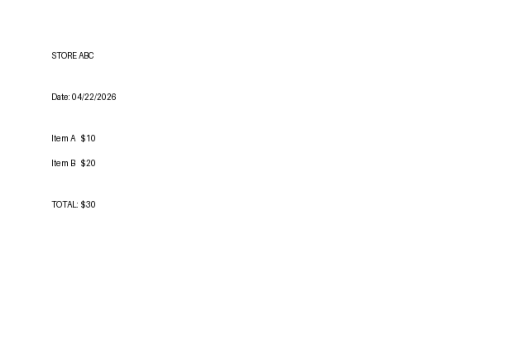

In [4]:
# Create artificial receipt image
img = Image.new('RGB', (600, 400), color='white')
draw = ImageDraw.Draw(img)

draw.text((50, 50), 'STORE ABC', fill='black')
draw.text((50, 100), 'Date: 04/22/2026', fill='black')
draw.text((50, 150), 'Item A   $10', fill='black')
draw.text((50, 180), 'Item B   $20', fill='black')
draw.text((50, 230), 'TOTAL: $30', fill='black')

img.save('receipt.png')

plt.imshow(img)
plt.axis('off')

In [5]:
text = pytesseract.image_to_string(img)

print("=== TESSERACT OUTPUT ===")
print(text)

=== TESSERACT OUTPUT ===
STORE ABC

Date: 04/22/2028

tema $10

tems $20

TOTAL $30



In [6]:
reader = easyocr.Reader(['en'])

result = reader.readtext('receipt.png')

print("=== EASYOCR OUTPUT ===")
for r in result:
    print(r[1])

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


=== EASYOCR OUTPUT ===
STORE ABC
Date. 04/22/2026
Item _
510
Item B $20
TOTAL: $30


(np.float64(-0.5), np.float64(599.5), np.float64(399.5), np.float64(-0.5))

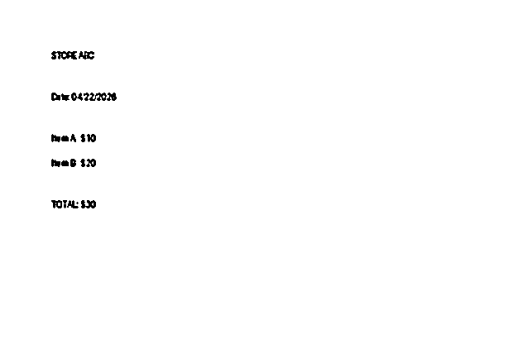

In [7]:
img_cv = cv2.imread('receipt.png')

gray = cv2.cvtColor(img_cv, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5,5), 0)

thresh = cv2.adaptiveThreshold(
    blur, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY, 11, 2
)

plt.imshow(thresh, cmap='gray')
plt.axis('off')

In [8]:
text2 = pytesseract.image_to_string(thresh)

print("=== AFTER PREPROCESSING ===")
print(text2)

=== AFTER PREPROCESSING ===
StorG ARS

Gre 04222028

twa $00

twas £20

TOU 890

